# Analysis 

## Cell 1: Importing Libraries & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual theme for the charts
sns.set_theme(style="whitegrid")

## Cell 2: Loading and Exploring the Data

In [6]:
# Load the dataset (adjusting the path to reach the 'data' folder)
df = pd.read_csv('C:/Users/clara/Projetos/netflix-data-analysis/data/netflix_titles.csv')

# Display the first 5 rows to understand the data structure
display(df.head())

# Show technical summary (data types, non-null counts)
print(df.info())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


## Cell 3: Data Cleaning & Preprocessing

In [7]:
# Fill missing values with "Unknown"
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['listed_in'] = df['listed_in'].fillna('Unknown')

# Convert the 'date_added' column from string to a proper datetime format
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format="%B %d, %Y", errors="coerce")

# Extract the year into a new column for easier trend analysis
df['year_added'] = df['date_added'].dt.year

# Verify if there are any remaining missing values
print(df.isnull().sum())

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
year_added      10
dtype: int64


## Cell 4: Analysis 1 - Movies vs. TV Shows Distribution

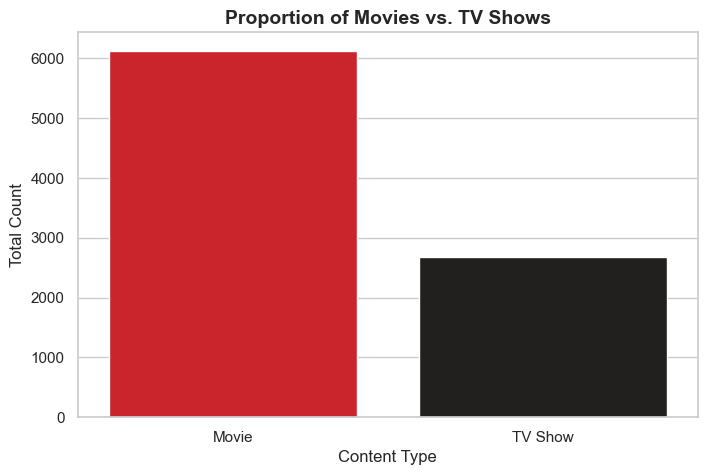

In [10]:
plt.figure(figsize=(8, 5))

# Adicionado hue='type' e legend=False para remover o warning
sns.countplot(data=df, x='type', hue='type', palette=['#E50914', '#221F1F'], legend=False)

plt.title('Proportion of Movies vs. TV Shows', fontsize=14, fontweight='bold')
plt.xlabel('Content Type')
plt.ylabel('Total Count')
plt.show()

## Cell 5: Analysis 2 - Top 10 Producing Countries

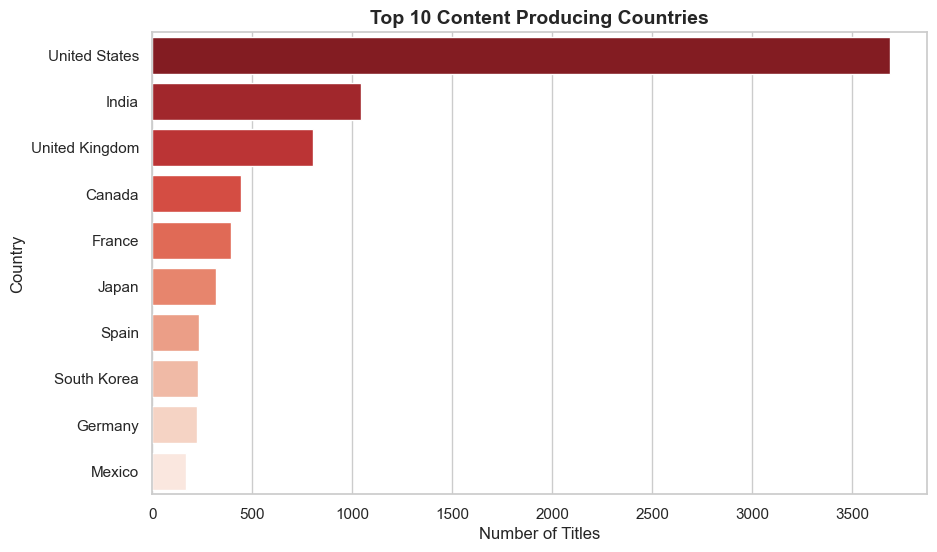

In [11]:
plt.figure(figsize=(10, 6))

# Split strings containing multiple countries, explode into separate rows, and remove 'Unknown'
countries = df['country'].str.split(', ').explode()
top_countries = countries[countries != 'Unknown'].value_counts().head(10)

# Adicionado hue=top_countries.index e legend=False para remover o warning
sns.barplot(y=top_countries.index, x=top_countries.values, hue=top_countries.index, palette='Reds_r', legend=False)

plt.title('Top 10 Content Producing Countries', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()